# Часть 1

## Этап 1

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from causalml.inference.meta import BaseSClassifier, BaseTClassifier, BaseXClassifier

from sklift.metrics import uplift_auc_score, qini_auc_score, uplift_at_k

In [49]:
df = pd.read_csv("uplift_fp_data.csv")

print("Размер датасета:", df.shape, end="\n")
print("Количество пропусков до обработки:")
print(df.isna().sum())

if df.isna().sum().sum() > 0:
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].median())
    print("\nПропуски были найдены и заполнены.")
else:
    print('\nПропусков нет, заполнение не требуется.')

print('\nКоличество пропусков после обработки:')
print(df.isna().sum())

Размер датасета: (64000, 10)
Количество пропусков до обработки:
recency            0
history_segment    0
history            0
mens               0
womens             0
zip_code           0
newbie             0
channel            0
treatment          0
target             0
dtype: int64

Пропусков нет, заполнение не требуется.

Количество пропусков после обработки:
recency            0
history_segment    0
history            0
mens               0
womens             0
zip_code           0
newbie             0
channel            0
treatment          0
target             0
dtype: int64


## Этап 2

### EDA


Размер контрольной группы: 42613
Размер тестовой группы: 21387

Статистика target по группам:
               mean       std   sum  count
treatment                                 
0          0.144463  0.351563  6156  42613
1          0.151400  0.358447  3238  21387


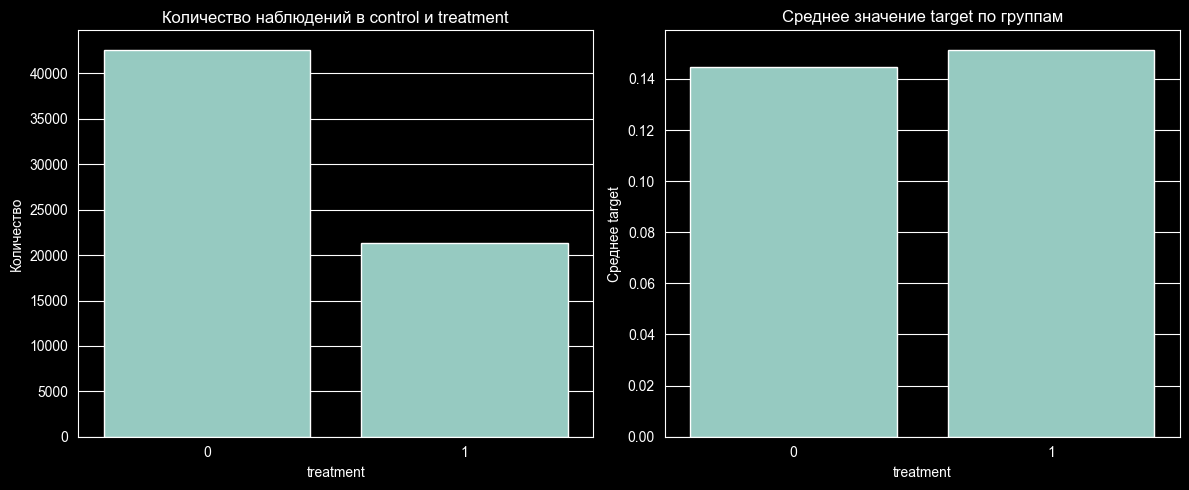

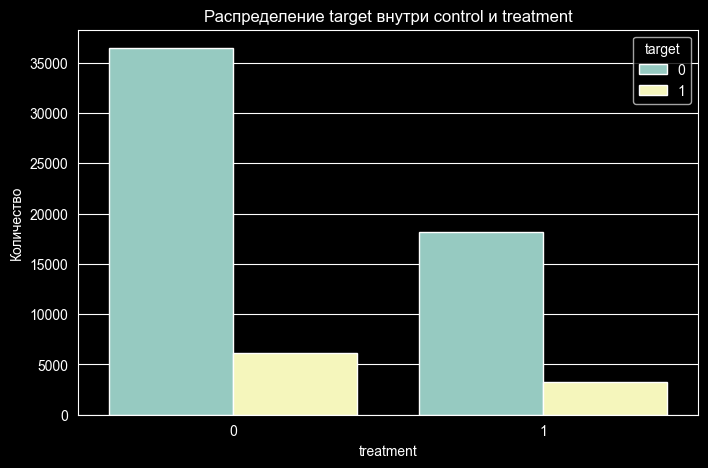

In [5]:
control_group = df[df["treatment"] == 0]
treatment_group = df[df["treatment"] == 1]

print('Размер контрольной группы:', control_group.shape[0])
print('Размер тестовой группы:', treatment_group.shape[0])

group_stats = df.groupby("treatment")["target"].agg(["mean", "std", "sum", "count"])
print('\nСтатистика target по группам:')
print(group_stats)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x="treatment")
plt.title('Количество наблюдений в control и treatment')
plt.xlabel('treatment')
plt.ylabel('Количество')

plt.subplot(1, 2, 2)
sns.barplot(data=df, x="treatment", y="target", errorbar=None)
plt.title('Среднее значение target по группам')
plt.xlabel('treatment')
plt.ylabel('Среднее target')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="treatment", hue="target")
plt.title('Распределение target внутри control и treatment')
plt.xlabel('treatment')
plt.ylabel('Количество')
plt.show()

По результатам EDA видно, что выборка несбалансирована по группам воздействия: в контрольной группе 42 613 наблюдений, а в тестовой 21 387. Это важно учитывать дальше при разбиении данных, поэтому лучше использовать стратификацию по `treatment` и `target`.

Среднее значение `target` в тестовой группе немного выше, чем в контрольной: 0.1514 против 0.1445. Это говорит о том, что промокод в среднем даёт положительный эффект, но разница небольшая, поэтому особенно важно использовать uplift-моделирование, чтобы находить именно тех пользователей, на которых воздействие работает лучше всего.

Также видно, что в обеих группах класс `target = 0` заметно преобладает над `target = 1`, то есть целевая переменная несбалансирована. Это значит, что при обучении моделей и интерпретации метрик нужно помнить о сравнительно низкой доле успешных откликов.


# Этап 2

### Проверка на статистическую значимость

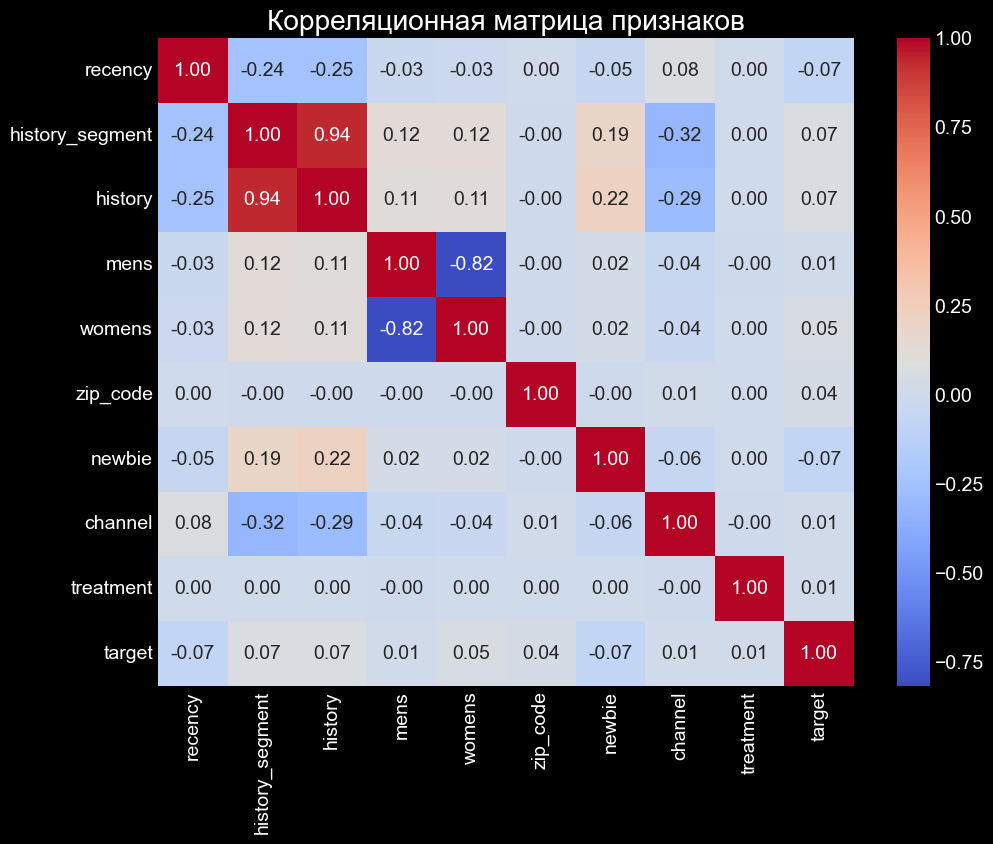

Корреляция признаков с target:
target             1.000000
history_segment    0.069734
history            0.065153
womens             0.051999
zip_code           0.037570
channel            0.010584
treatment          0.009247
mens               0.006712
newbie            -0.073924
recency           -0.074765
Name: target, dtype: float64


In [59]:
corr_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корреляционная матрица признаков')
plt.show()

target_corr = corr_matrix['target'].sort_values(ascending=False)
print('Корреляция признаков с target:')
print(target_corr)

Для проверки статистической значимости различий между контрольной и тестовой группами был выбран t-test.

Причина выбора:
- данные разделены на две независимые группы: `treatment = 0` и `treatment = 1`;
- нас интересует, различается ли среднее значение `target` между этими группами;
- среднее значение бинарной переменной `target` можно интерпретировать как конверсию;
- выборка большая, поэтому t-test можно использовать для сравнения средних значений между двумя группами.

Если `p-value < 0.05`, различия между группами считаются статистически значимыми.

## Построение корреляций

In [7]:
control_group_target = control_group["target"]
treatment_group_target = treatment_group["target"]

print('Среднее значение target в control:', control_group_target.mean())
print('Стандартное отклонение в control:', control_group_target.std())

print('\nСреднее значение target в treatment:', treatment_group_target.mean())
print('Стандартное отклонение в treatment:', treatment_group_target.std())

t_stat, p_value = ttest_ind(control_group_target, treatment_group_target, equal_var=False)

print('\nt-statistic:', t_stat)
print('p-value:', p_value)

if p_value < 0.05:
    print('Различия между группами статистически значимы.')
else:
    print('Статистически значимых различий между группами нет.')

Среднее значение target в control: 0.14446295731349587
Стандартное отклонение в control: 0.3515626711050198

Среднее значение target в treatment: 0.151400383410483
Стандартное отклонение в treatment: 0.3584470880102957

t-statistic: -2.3243826621990147
p-value: 0.02010972691485792
Различия между группами статистически значимы.


По корреляционной матрице видно, что сильнее всего с целевой переменной `target` связаны признаки `history_segment` (0.07), `history` (0.07), `womens` (0.05), `zip_code` (0.04), а также отрицательно связаны `newbie` (-0.07) и `recency` (-0.07). При этом сами значения корреляции невысокие, поэтому можно сделать вывод, что сильной линейной зависимости между отдельными признаками и таргетом нет. Это значит, что для решения задачи лучше использовать модель, которая умеет учитывать комбинации признаков, а не опираться только на простые линейные зависимости.

Среди самих признаков наблюдаются более заметные связи. Самая сильная положительная корреляция наблюдается между `history_segment` и `history` (0.94), что логично, так как сегмент истории расходов напрямую связан с общей суммой прошлых трат. Также заметна сильная отрицательная корреляция между `mens` и `womens` (-0.82), что может говорить о различии покупательских предпочтений клиентов.

В целом данные не содержат слишком большого количества сильных зависимостей с таргетом, но есть несколько признаков, которые могут быть полезны для модели в сочетании друг с другом. Это дополнительно подтверждает, что для задачи uplift-моделирования стоит использовать более гибкие модели, способные находить сложные закономерности.


## Этап 3

В качестве baseline-модели была выбрана uplift-модель типа S-learner.

Причины выбора:
- S-learner является одним из самых простых и понятных подходов в uplift-моделировании;
- модель обучается один раз на всех данных сразу, используя признак `treatment` как один из входных признаков;
- такой подход удобен как базовая точка отсчёта, потому что он позволяет быстро получить первые uplift-предсказания и сравнить их с более сложными методами;
- S-learner хорошо подходит для учебного проекта, так как его проще интерпретировать и объяснить.

В качестве базового алгоритма внутри uplift-модели будет использован `RandomForestClassifier`, потому что он умеет находить нелинейные зависимости и взаимодействия между признаками, что важно для задачи uplift-моделирования. Кроме того, случайный лес устойчив к шуму и хорошо работает на смешанных по смыслу признаках.

После обучения baseline-модели её результаты будут сравнены с другими подходами, чтобы понять, даёт ли более сложная архитектура прирост по метрикам uplift.


### Советы по обучению и инференсу моделей
1. Некоторые uplift модели из библиотеки `causalml` будут требовать категориальные значения воздействия. Для этого используйте маппинг
#### Пример использования маппинга
```python
treatment_mapping = {
    0: 'control',
    1: 'treatment'
}
treatment_train_mapped = treatment_train.map(treatment_mapping)
treatment_test_mapped = treatment_test.map(treatment_mapping)
```

2. При вызове метода `.predict` и получения метрик для тестовой выборки не забывайте применять к прогнозам метод `squeeze()`, чтобы преобразовать многомерный массив в одномерный, что поможет получить адекватные метрики.

3. Для воспроизводимости результатов и объективной оценки не забывайте применять `random_state=42` для моделей, а также при разделении выборки

### Разбиение выборки на тренировочную и тестовую

In [10]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=df[["target", "treatment"]],
    random_state=42
)

treatment_train = X_train["treatment"]
treatment_test = X_test["treatment"]

print('Размер X_train:', X_train.shape)
print('Размер X_test:', X_test.shape)
print('Размер y_train:', y_train.shape)
print('Размер y_test:', y_test.shape)

print('\nРаспределение treatment в train:')
print(treatment_train.value_counts(normalize=True))

print('\nРаспределение treatment в test:')
print(treatment_test.value_counts(normalize=True))

print('\nСреднее значение target в train:', y_train.mean())
print('Среднее значение target в test:', y_test.mean())

Размер X_train: (51200, 9)
Размер X_test: (12800, 9)
Размер y_train: (51200,)
Размер y_test: (12800,)

Распределение treatment в train:
treatment
0    0.66584
1    0.33416
Name: proportion, dtype: float64

Распределение treatment в test:
treatment
0    0.665781
1    0.334219
Name: proportion, dtype: float64

Среднее значение target в train: 0.14677734375
Среднее значение target в test: 0.146796875


### Обучение выбранного бейзлайна

In [18]:
feature_cols = [col for col in X_train.columns if col != "treatment"]

base_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_split=50,
    random_state=42,
    n_jobs=-1
)

s_learner = BaseSClassifier(
    learner=base_model,
    control_name=0
)

s_learner.fit(
    X=X_train[feature_cols].values,
    treatment=treatment_train.values,
    y=y_train.values
)

print('Baseline S-learner обучен.')
print('Используемые признаки:', feature_cols)

Baseline S-learner обучен.
Используемые признаки: ['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel']


### Расчет метрик для выбранного бейзлайна на тестовой выборке

                model  uplift_auc  qini_auc  uplift_at_30
0  S-learner baseline    0.026613  0.059106      0.039187
Метрики baseline-модели:
Uplift AUC: 0.0266
Qini AUC: 0.0591
Uplift@30: 0.0392


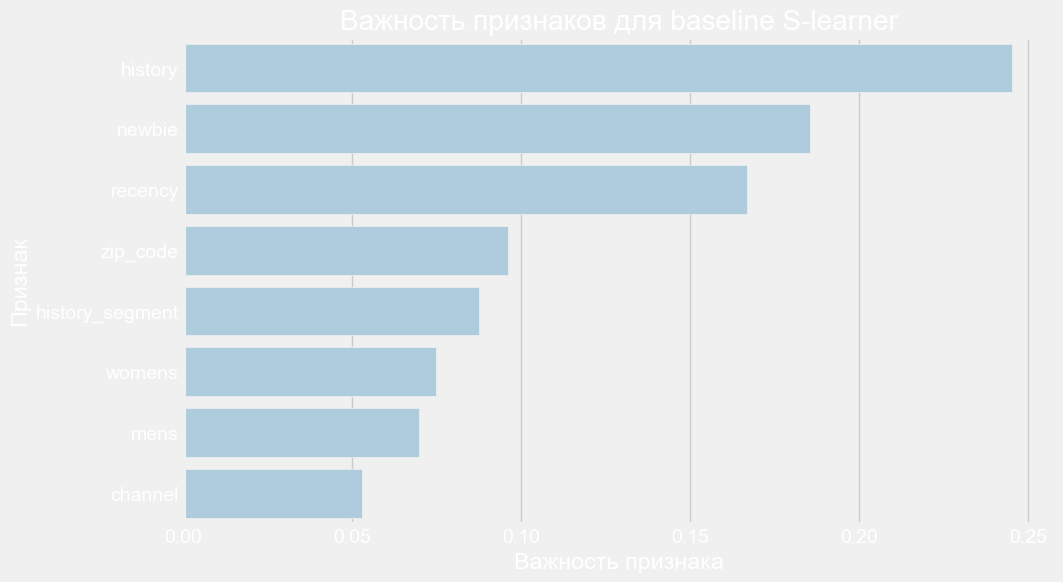

In [24]:
uplift_pred_s = s_learner.predict(X_test[feature_cols].values).squeeze()

uplift_auc_s = uplift_auc_score(y_test.values, uplift_pred_s, treatment_test.values)
qini_auc_s = qini_auc_score(y_test.values, uplift_pred_s, treatment_test.values)

uplift_at_30_s = uplift_at_k(
    y_test.values,
    uplift_pred_s,
    treatment_test.values,
    strategy='overall',
    k=0.3
)

baseline_metrics = pd.DataFrame({
    "model": ["S-learner baseline"],
    "uplift_auc": [uplift_auc_s],
    "qini_auc": [qini_auc_s],
    "uplift_at_30": [uplift_at_30_s]
})

print(baseline_metrics)

fitted_s_model = s_learner.models[1]

feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": fitted_s_model.feature_importances_[1:],
}).sort_values("importance", ascending=False)

print('Метрики baseline-модели:')
print(f'Uplift AUC: {uplift_auc_s:.4f}')
print(f'Qini AUC: {qini_auc_s:.4f}')
print(f'Uplift@30: {uplift_at_30_s:.4f}')

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x="importance", y="feature")
plt.title('Важность признаков для baseline S-learner')
plt.xlabel('Важность признака')
plt.ylabel('Признак')
plt.show()

# Обучение 2 моделей 

### Обучение модели 1

In [23]:
treatment_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_split=50,
    random_state=42,
    n_jobs=-1
)

control_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_split=50,
    random_state=42,
    n_jobs=-1
)

t_learner = BaseTClassifier(
    treatment_learner=treatment_model,
    control_learner=control_model,
    control_name=0
)

t_learner.fit(
    X=X_train[feature_cols].values,
    treatment=treatment_train.values,
    y=y_train.values
)

print('T-learner обучен.')

T-learner обучен.


### Получение метрик по модели 1

In [25]:
uplift_pred_t = t_learner.predict(X_test[feature_cols].values).squeeze()

uplift_auc_t = uplift_auc_score(y_test.values, uplift_pred_t, treatment_test.values)
qini_auc_t = qini_auc_score(y_test.values, uplift_pred_t, treatment_test.values)
uplift_at_30_t = uplift_at_k(
    y_test.values,
    uplift_pred_t,
    treatment_test.values,
    strategy='overall',
    k=0.3
)

t_metrics = pd.DataFrame({
    "model": ["T-learner"],
    "uplift_auc": [uplift_auc_t],
    "qini_auc": [qini_auc_t],
    "uplift_at_30": [uplift_at_30_t]
})

print(t_metrics)

print('Метрики T-learner:')
print(f'Uplift AUC: {uplift_auc_t:.4f}')
print(f'Qini AUC: {qini_auc_t:.4f}')
print(f'Uplift@30: {uplift_at_30_t:.4f}')

       model  uplift_auc  qini_auc  uplift_at_30
0  T-learner    0.030252  0.067678      0.043848
Метрики T-learner:
Uplift AUC: 0.0303
Qini AUC: 0.0677
Uplift@30: 0.0438


### Обучение модели 2

In [31]:
propensity_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

propensity_model.fit(X_train[feature_cols], treatment_train)

p_train = propensity_model.predict_proba(X_train[feature_cols])[:, 1]
p_test = propensity_model.predict_proba(X_test[feature_cols])[:, 1]

x_learner = BaseXClassifier(
    outcome_learner=RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=50,
        random_state=42,
        n_jobs=-1
    ),
    effect_learner=RandomForestRegressor(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=50,
        random_state=42,
        n_jobs=-1
    ),
    control_name=0
)

x_learner.fit(
    X=X_train[feature_cols].values,
    treatment=treatment_train.values,
    y=y_train.values,
    p=p_train
)

print('X-learner обучен.')

X-learner обучен.


### Получение метрик по модели 2

In [32]:
uplift_pred_x = x_learner.predict(
    X_test[feature_cols].values,
    p=p_test
).squeeze()

uplift_auc_x = uplift_auc_score(y_test.values, uplift_pred_x, treatment_test.values)
qini_auc_x = qini_auc_score(y_test.values, uplift_pred_x, treatment_test.values)
uplift_at_30_x = uplift_at_k(
    y_test.values,
    uplift_pred_x,
    treatment_test.values,
    strategy='overall',
    k=0.3
)

x_metrics = pd.DataFrame({
    "model": ["X-learner"],
    "uplift_auc": [uplift_auc_x],
    "qini_auc": [qini_auc_x],
    "uplift_at_30": [uplift_at_30_x]
})

print(x_metrics)

print('Метрики X-learner:')
print(f'Uplift AUC: {uplift_auc_x:.4f}')
print(f'Qini AUC: {qini_auc_x:.4f}')
print(f'Uplift@30: {uplift_at_30_x:.4f}')

       model  uplift_auc  qini_auc  uplift_at_30
0  X-learner    0.030859  0.068775      0.048649
Метрики X-learner:
Uplift AUC: 0.0309
Qini AUC: 0.0688
Uplift@30: 0.0486


По результатам обучения трёх uplift-моделей лучшей оказалась модель `X-learner`.

Сравнение моделей показало:
- `S-learner baseline`: `Uplift@30 = 0.0392`
- `T-learner`: `Uplift@30 = 0.0438`
- `X-learner`: `Uplift@30 = 0.0486`

Также `X-learner` показал лучшие значения по метрикам `Uplift AUC` и `Qini AUC`, что говорит о более качественном ранжировании клиентов по ожидаемому эффекту воздействия.

Различия в качестве моделей можно объяснить их устройством. `S-learner` обучает одну общую модель для всех наблюдений и может хуже выделять различия между контрольной и тестовой группами. `T-learner` уже строит две отдельные модели, поэтому лучше улавливает различия между группами. `X-learner` является более гибким подходом, так как отдельно моделирует ожидаемые исходы и индивидуальный эффект воздействия, за счёт чего лучше подходит для задачи uplift-моделирования.

Таким образом, для дальнейшего улучшения имеет смысл выбрать именно `X-learner`, так как он показал наилучшее качество по ключевой для проекта метрике `Uplift@30`.


# Часть 2

## Этап 1
Улучшите бейзлайн выбранной модели

In [53]:
models_comparison = pd.DataFrame({
    "model": ["S-learner", "T-learner", "X-learner"],
    'uplift_auc': [uplift_auc_s, uplift_auc_t, uplift_auc_x],
    'qini_auc': [qini_auc_s, qini_auc_t, qini_auc_x],
    'uplift_at_30': [uplift_at_30_s, uplift_at_30_t, uplift_at_30_x]
}).sort_values('uplift_at_30', ascending=False)

print(models_comparison)

print('Лучшая baseline-модель по Uplift@30:', models_comparison.iloc[0]['model'])

train_stratify = pd.concat(
    [y_train.rename("target"), treatment_train.rename("treatment")],
    axis=1
)

X_train_tune, X_val, y_train_tune, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    stratify=train_stratify,
    random_state=42
)

treatment_train_tune = X_train_tune["treatment"]
treatment_val = X_val["treatment"]

print("Размер train для тюнинга:", X_train_tune.shape)
print("Размер validation:", X_val.shape)
print("Размер финального test:", X_test.shape)

def train_eval_x_learner(
    X_train_data,
    X_eval_data,
    y_train_data,
    y_eval_data,
    treatment_train_data,
    treatment_eval_data,
    features_list,
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=50,
):
    propensity_model = LogisticRegression(
        max_iter=5000,
        random_state=42
    )

    propensity_model.fit(X_train_data[features_list], treatment_train_data)

    p_train_local = propensity_model.predict_proba(X_train_data[features_list])[:, 1]
    p_eval_local = propensity_model.predict_proba(X_eval_data[features_list])[:, 1]

    model = BaseXClassifier(
        outcome_learner=RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_state=42,
            n_jobs=-1
        ),
        effect_learner=RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_state=42,
            n_jobs=-1
        ),
        control_name=0
    )

    model.fit(
        X=X_train_data[features_list].values,
        treatment=treatment_train_data.values,
        y=y_train_data.values,
        p=p_train_local
    )

    uplift_pred = model.predict(
        X_eval_data[features_list].values,
        p=p_eval_local
    ).squeeze()

    uplift_auc = uplift_auc_score(y_eval_data.values, uplift_pred, treatment_eval_data.values)
    qini_auc = qini_auc_score(y_eval_data.values, uplift_pred, treatment_eval_data.values)
    uplift_at_30 = uplift_at_k(
        y_eval_data.values,
        uplift_pred,
        treatment_eval_data.values,
        strategy='overall',
        k=0.3
    )

    return model, propensity_model, uplift_pred, uplift_auc, qini_auc, uplift_at_30


best_model, best_propensity_model, best_uplift_pred, best_uplift_auc, best_qini_auc, best_uplift_at_30 = train_eval_x_learner(
    X_train,
    X_test,
    y_train,
    y_test,
    treatment_train,
    treatment_test,
    feature_cols
)

print(f'Baseline X-learner, Uplift@30: {best_uplift_at_30:.4f}')

       model  uplift_auc  qini_auc  uplift_at_30
2  X-learner    0.030859  0.068775      0.048649
1  T-learner    0.030252  0.067678      0.043848
0  S-learner    0.026613  0.059106      0.039187
Лучшая baseline-модель по Uplift@30: X-learner
Размер train для тюнинга: (38400, 9)
Размер validation: (12800, 9)
Размер финального test: (12800, 9)
Baseline X-learner, Uplift@30: 0.0486


#### Генерация признаков (опционально)

In [58]:
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

for data_part in [X_train_fe, X_test_fe]:
    data_part["history_per_recency"] = data_part["history"] / (data_part["recency"] + 1)
    data_part["history_x_segment"] = data_part["history"] * (data_part["history_segment"] + 1)
    data_part["mens_womens"] = data_part["mens"] * data_part["womens"]
    data_part["zip_channel"] = data_part["zip_code"] * data_part["channel"]

feature_cols_fe = [col for col in X_train_fe.columns if col != "treatment"]

print('Количество признаков до генерации:', len(feature_cols))
print('Количество признаков после генерации:', len(feature_cols_fe))
print('\nДобавленные признаки:')
print([col for col in feature_cols_fe if col not in feature_cols])

fe_model, fe_propensity_model, fe_uplift_pred, fe_uplift_auc, fe_qini_auc, fe_uplift_at_30 = train_eval_x_learner(
    X_train_fe,
    X_test_fe,
    y_train,
    y_test,
    treatment_train,
    treatment_test,
    feature_cols_fe
)

print(f'\nX-learner с новыми признаками, Uplift AUC: {fe_uplift_auc:.4f}')
print(f'X-learner с новыми признаками, Qini AUC: {fe_qini_auc:.4f}')
print(f'X-learner с новыми признаками, Uplift@30: {fe_uplift_at_30:.4f}')

Количество признаков до генерации: 8
Количество признаков после генерации: 12

Добавленные признаки:
['history_per_recency', 'history_x_segment', 'mens_womens', 'zip_channel']

X-learner с новыми признаками, Uplift AUC: 0.0323
X-learner с новыми признаками, Qini AUC: 0.0722
X-learner с новыми признаками, Uplift@30: 0.0468


Были сгенерированы дополнительные признаки, однако они не улучшили качество модели по метрике `Uplift@30`, поэтому в финальную версию модели они включены не были.

### Подбор гиперпараметров

In [54]:
from optuna import create_study
from sklift.metrics import uplift_at_k

def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 100, 400, step=50)
    max_depth = trial.suggest_int("max_depth", 4, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 20, 100, step=10)

    _, _, _, _, _, uplift_at_30 = train_eval_x_learner(
        X_train_tune,
        X_val,
        y_train_tune,
        y_val,
        treatment_train_tune,
        treatment_val,
        feature_cols,
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf
    )
    return uplift_at_30

# Создаем и запускаем исследование
study = create_study(direction='maximize')
study.optimize(objective, n_trials=20)

# Выводим лучшие гиперпараметры
print("Best hyperparameters: ", study.best_params)
print("Best validation Uplift@30: ", study.best_value)


Best hyperparameters:  {'n_estimators': 100, 'max_depth': 7, 'min_samples_leaf': 90}
Best score:  0.03918985054398974


In [55]:
final_model, final_propensity_model, final_uplift_pred, final_uplift_auc, final_qini_auc, final_uplift_at_30 = train_eval_x_learner(
    X_train,
    X_test,
    y_train,
    y_test,
    treatment_train,
    treatment_test,
    feature_cols,
    n_estimators=study.best_params["n_estimators"],
    max_depth=study.best_params["max_depth"],
    min_samples_leaf=study.best_params["min_samples_leaf"]
)

print("Финальные метрики улучшенной модели на test:")
print(f"Uplift AUC: {final_uplift_auc:.4f}")
print(f"Qini AUC: {final_qini_auc:.4f}")
print(f"Uplift@30: {final_uplift_at_30:.4f}")

Финальные метрики улучшенной модели на test:
Uplift AUC: 0.0299
Qini AUC: 0.0665
Uplift@30: 0.0360


## Этап 2

### Визуализация результатов

In [39]:
from utils import custom_uplift_by_percentile

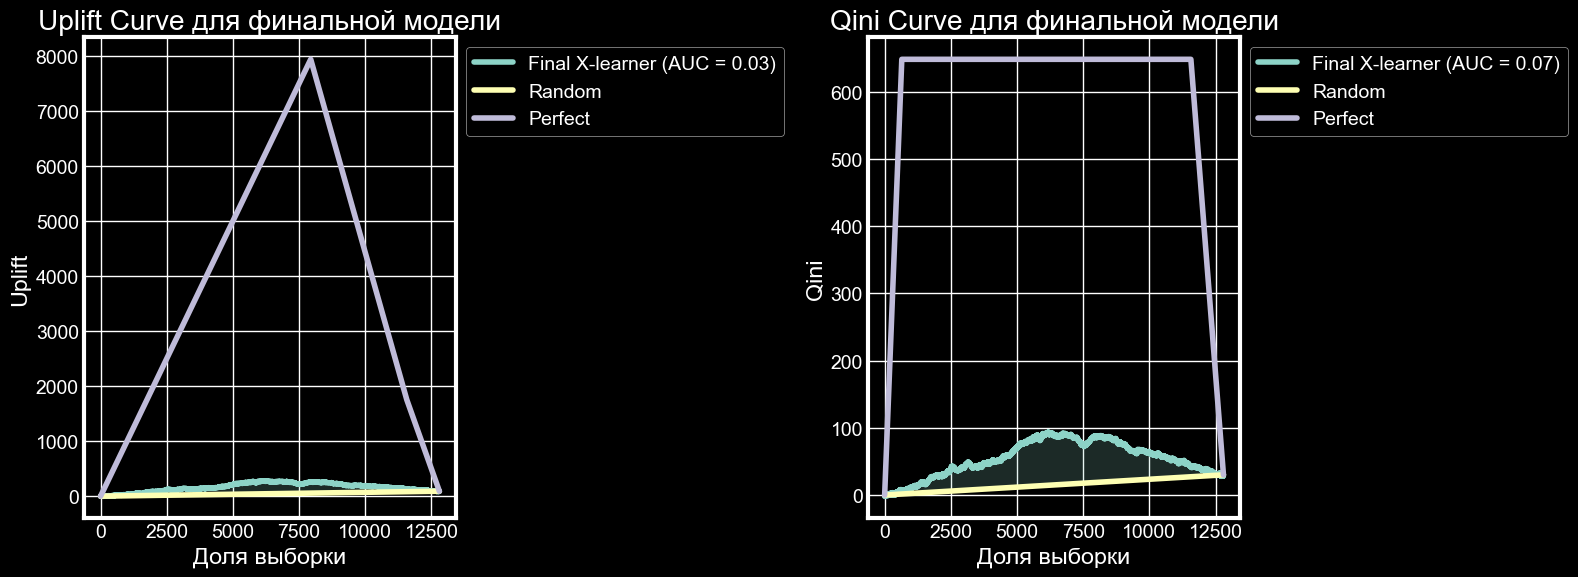

In [56]:
from sklift.viz import plot_uplift_curve, plot_qini_curve

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_uplift_curve(
    y_test.values,
    final_uplift_pred,
    treatment_test.values,
    ax=axes[0],
    name="Final X-learner"
)
axes[0].set_title('Uplift Curve для финальной модели')
axes[0].set_xlabel('Доля выборки')
axes[0].set_ylabel('Uplift')

plot_qini_curve(
    y_test.values,
    final_uplift_pred,
    treatment_test.values,
    ax=axes[1],
    name='Final X-learner'
)
axes[1].set_title('Qini Curve для финальной модели')
axes[1].set_xlabel('Доля выборки')
axes[1].set_ylabel('Qini')

plt.tight_layout()
plt.show()

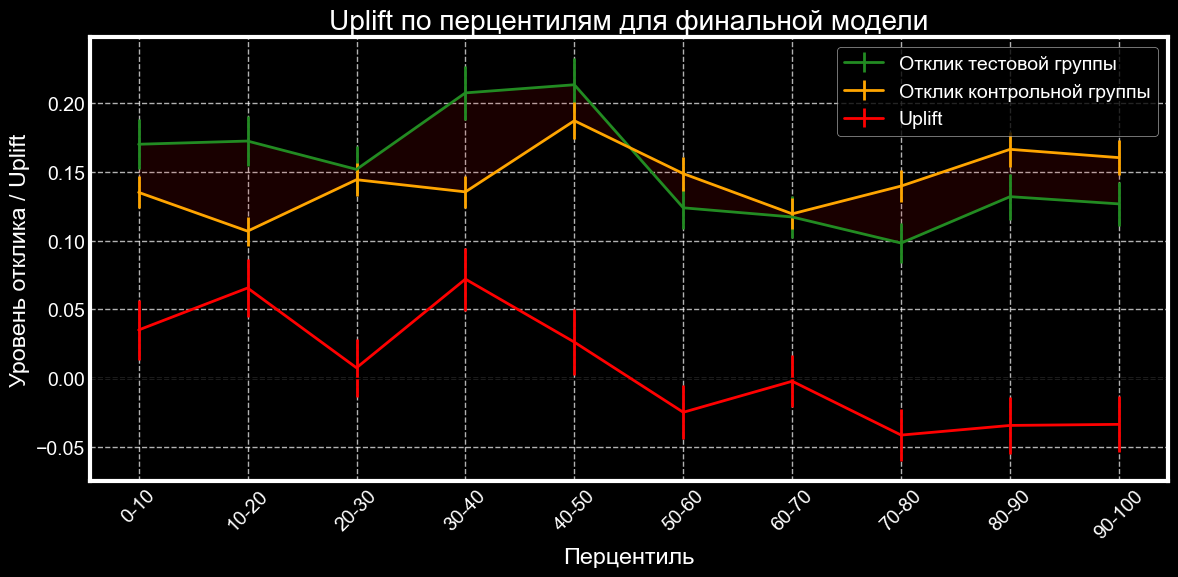

In [57]:
custom_uplift_by_percentile(
    y_true=y_test.values,
    uplift=final_uplift_pred,
    treatment=treatment_test.values,
    kind="line",
    bins=10,
    figsize=(12, 6),
    title="Uplift по перцентилям для финальной модели"
)

plt.show()

Финальная модель показала `Uplift@30 = 0.0360`, что соответствует уровню `удовлетворительно` по критериям проекта. Это означает, что модель лучше случайного отбора выделяет клиентов, которым стоит отправлять промокод, но запас для улучшения качества ещё остаётся.

По графикам `Uplift Curve` и `Qini Curve` видно, что модель ранжирует клиентов лучше случайного подхода. На графике `uplift by percentile` положительный uplift наблюдается в верхних перцентилях, а дальше снижается и местами становится отрицательным. Это значит, что модель лучше использовать для отбора верхней части клиентов, а не для массовой рассылки по всей базе.

Дальше качество можно улучшать за счёт более широкого подбора гиперпараметров, экспериментов с другими базовыми алгоритмами, например CatBoost или XGBoost, а также более удачной генерации признаков.

# Этап 3

In [41]:
# Класс для инференса модели
class UpliftModelInference:
    """
    Класс для инференса uplift модели.
    """
    
    def __init__(self, model, propensity_model, feature_names, logger=None):
        """
        Инициализация класса.
        
        Аргументы:
            model: Обученная модель uplift
            feature_names: Список признаков для предсказания 
            logger: Объект для логирования (по умолчанию None)
        """
        self.model = model
        self.propensity_model = propensity_model
        self.feature_names = feature_names
        self.logger = logger
        
        if self.logger:
            self.logger.info("Модель UpliftModel инициализирована с признаками: %s", feature_names)

    def _transform_data(self, X):
        """
        Преобразование данных для модели.
        
        Аргументы:
            X: pandas.DataFrame с признаками
        """
        if self.logger:
            self.logger.debug("Преобразование входных данных размерности %s", X.shape)

        X = X.copy()
        X = X[self.feature_names]
       

        return X
    
    def predict(self, X):
        """
        Получение предсказаний uplift.
        
        Аргументы:
            X: pandas.DataFrame с признаками
            
        Возвращает:
            numpy.array с предсказанными значениями uplift
        """
        # Проверяем, что датафрейм не пустой
        if X.empty:
            if self.logger:
                self.logger.error("Предоставлен пустой датафрейм")
            return None

        if X.isnull().any().any():
            if self.logger:
                self.logger.error("Входные данные содержат пропущенные значения")
            return [None]*len(X)

        missing_features = set(self.feature_names) - set(X.columns)
        if missing_features:
            error_msg = f"Отсутствуют признаки: {missing_features}"
            if self.logger:
                self.logger.error(error_msg)

            return [None]*len(X)

        if self.logger:
            self.logger.info("Выполняем предсказания для данных размерности %s", X.shape)

        X = self._transform_data(X)

        p = self.propensity_model.predict_proba(X)[:, 1]
        uplift = self.model.predict(X.values, p=p).squeeze()

        if self.logger:
            self.logger.info("Предсказания успешно завершены")
            
        return uplift


In [60]:
model = UpliftModelInference(
    model=final_model,
    propensity_model=final_propensity_model,
    feature_names=feature_cols,
)

In [61]:
test_data = pd.DataFrame({
            'recency': [1, 2, 3],
            'history_segment': [1, 2, 3], 
            'history': [100, 200, 300],
            'mens': [1, 0, 1],
            'womens': [0, 1, 0],
            'zip_code': [1, 0, 1],
            'newbie': [0, 1, 0],
            'channel': [1, 2, 0]
        })

In [62]:
# проверка работы класса
model.predict(test_data)

array([-0.02865757,  0.01952418, -0.03163346])

Для передачи модели в продакшн был доработан класс `UpliftModelInference`. В нём реализован метод `_transform_data`, который подготавливает входные признаки, и метод `predict`, который возвращает uplift-предсказания для новых объектов.

Так как финальная модель основана на `X-learner`, для инференса дополнительно используется модель расчёта `propensity score`. Проверка на тестовом примере показала, что класс корректно возвращает предсказания uplift.